# Image–Text Matching System Using CLIP

### Project Objective
Determine which text description is most semantically related to a given image using **CLIP (Contrastive Language–Image Pre-training)**.

**Platform:** Google Colab  
**Model:** `openai/clip-vit-base-patch32`  
**Method:** CLIP embeddings + cosine similarity + ranking

## Important Colab Setup

This notebook is designed specifically for Google Colab.

**Do not upgrade NumPy, Requests, PyTorch, or other Colab-managed packages.**

The installation cell below installs only `transformers`. This prevents dependency conflicts such as:

- `google-colab` requiring a specific Requests version
- `numba` requiring a compatible NumPy version
- CUDA/PyTorch version conflicts

If you previously ran a notebook that upgraded packages and now see dependency warnings/errors, use:

**Runtime → Factory reset runtime**

and then run this notebook from the beginning.

In [1]:
# Install ONLY the library needed for CLIP.
# Google Colab already provides PyTorch, NumPy, Requests,
# Pillow, Matplotlib and other common packages.

!pip -q install transformers

## 1. Import Libraries

In [2]:
import io
import requests
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display
from transformers import CLIPModel, CLIPProcessor

print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)
print("Requests version:", requests.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Transformers imported successfully.")

PyTorch version: 2.11.0+cpu
NumPy version: 2.1.3
Requests version: 2.32.4
CUDA available: False
Transformers imported successfully.


## 2. Select CPU or GPU

The project automatically uses a GPU when Colab provides one.

For faster execution, you can select:

**Runtime → Change runtime type → T4 GPU**

A CPU also works; it will simply be slower.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "openai/clip-vit-base-patch32"

print("Device:", device)
print("Model:", MODEL_NAME)

Device: cpu
Model: openai/clip-vit-base-patch32


## 3. Load the Pre-trained CLIP Model

In [4]:
print("Loading CLIP model...")

model = CLIPModel.from_pretrained(MODEL_NAME)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

model = model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())

print("CLIP model loaded successfully.")
print(f"Total parameters: {total_params / 1e6:.1f} million")
print("Running on:", device)

Loading CLIP model...


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded successfully.
Total parameters: 151.3 million
Running on: cpu


## 4. How CLIP Works

CLIP has two main encoders:

- **Image Encoder** → image embedding
- **Text Encoder** → text embedding

The embeddings are represented in a shared semantic space.

```text
Image
  ↓
CLIP Image Encoder
  ↓
Image Embedding
  ↓
Cosine Similarity
  ↑
Text Embeddings
  ↑
CLIP Text Encoder
  ↑
Candidate Descriptions
```

The candidate description with the highest similarity is selected.

## 5. Image Loading Function

In [5]:
def load_image(source):
    """Load an RGB image from a URL, local path, or PIL Image."""

    if isinstance(source, Image.Image):
        return source.convert("RGB")

    if not isinstance(source, str):
        raise TypeError(
            "Image source must be a URL, local path, or PIL Image."
        )

    if source.startswith(("http://", "https://")):
        response = requests.get(
            source,
            timeout=30,
            headers={"User-Agent": "Mozilla/5.0"}
        )
        response.raise_for_status()
        return Image.open(io.BytesIO(response.content)).convert("RGB")

    return Image.open(source).convert("RGB")

## 6. Download Sample Images

In [6]:
# COCO validation images used only as project demonstrations.
# If a network request fails, the notebook continues and you can
# use your own uploaded image in the next section.

sample_urls = {
    "cats": "https://images.cocodataset.org/val2017/000000039769.jpg",
    "stop sign": "https://images.cocodataset.org/val2017/000000000724.jpg",
    "bedroom": "https://images.cocodataset.org/val2017/000000000632.jpg",
    "living room": "https://images.cocodataset.org/val2017/000000000139.jpg",
    "bear": "https://images.cocodataset.org/val2017/000000000285.jpg",
}

sample_images = {}

for name, url in sample_urls.items():
    try:
        sample_images[name] = load_image(url)
        print("Loaded:", name)
    except Exception as e:
        print(f"Skipped {name}: {type(e).__name__}: {e}")

print("Number of sample images loaded:", len(sample_images))

Skipped cats: SSLError: HTTPSConnectionPool(host='images.cocodataset.org', port=443): Max retries exceeded with url: /val2017/000000039769.jpg (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'images.cocodataset.org'. (_ssl.c:1032)")))
Skipped stop sign: SSLError: HTTPSConnectionPool(host='images.cocodataset.org', port=443): Max retries exceeded with url: /val2017/000000000724.jpg (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'images.cocodataset.org'. (_ssl.c:1032)")))
Skipped bedroom: SSLError: HTTPSConnectionPool(host='images.cocodataset.org', port=443): Max retries exceeded with url: /val2017/000000000632.jpg (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'ima

In [7]:
if sample_images:
    count = len(sample_images)

    fig, axes = plt.subplots(
        1, count,
        figsize=(4 * count, 4)
    )

    if count == 1:
        axes = [axes]

    for ax, (name, image) in zip(axes, sample_images.items()):
        ax.imshow(image)
        ax.set_title(name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No sample images loaded.")

No sample images loaded.


## 7. Upload Your Own Image

Saving anime-g.jpg to anime-g.jpg
Uploaded: anime-g.jpg


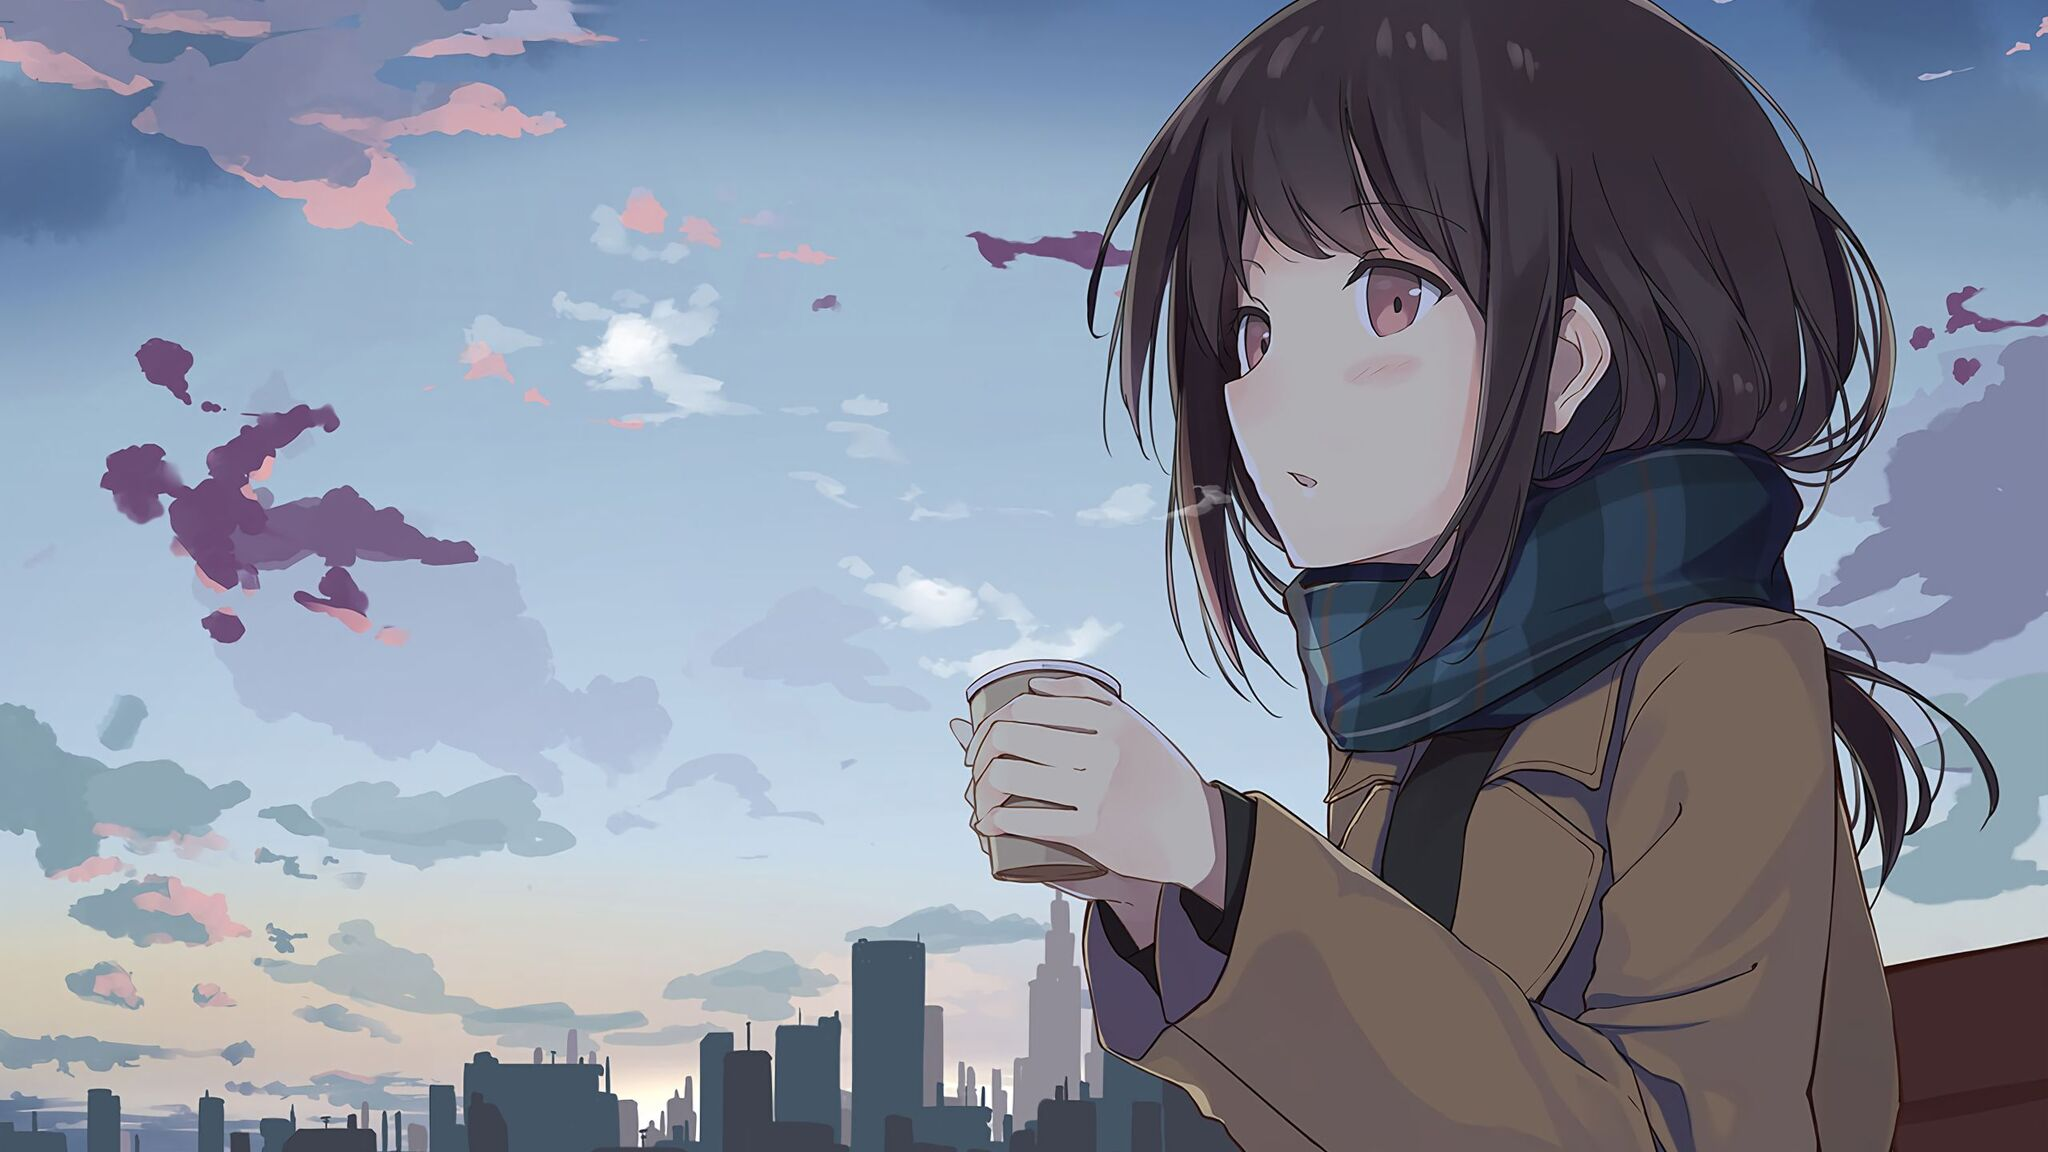

In [8]:
from google.colab import files

uploaded = files.upload()

user_image = None
uploaded_name = None

if uploaded:
    uploaded_name = next(iter(uploaded))
    user_image = load_image(uploaded_name)

    print("Uploaded:", uploaded_name)
    display(user_image)
else:
    print("No image uploaded.")

## 8. Core Image–Text Matching Function

This function:

1. Receives one image.
2. Receives multiple candidate descriptions.
3. Preprocesses image and text.
4. Runs CLIP inference.
5. Calculates image-to-text similarity.
6. Converts the scores into relative softmax scores.
7. Returns embeddings for additional cosine-similarity analysis.

In [9]:
def move_batch_to_device(batch, target_device):
    return {
        key: value.to(target_device) if hasattr(value, "to") else value
        for key, value in batch.items()
    }


def match_image_to_texts(image, texts):
    """Compare one image with multiple candidate text descriptions."""

    if not isinstance(image, Image.Image):
        image = load_image(image)

    if texts is None:
        raise ValueError("texts cannot be None.")

    cleaned_texts = [
        str(text).strip()
        for text in texts
        if str(text).strip()
    ]

    if len(cleaned_texts) == 0:
        raise ValueError("Provide at least one non-empty description.")

    inputs = processor(
        text=cleaned_texts,
        images=image,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    inputs = move_batch_to_device(inputs, device)

    with torch.inference_mode():
        outputs = model(**inputs)

        logits = outputs.logits_per_image[0]

        relative_scores = torch.softmax(logits, dim=0)

        image_embeddings = outputs.image_embeds
        text_embeddings = outputs.text_embeds

    return (
        relative_scores.detach().cpu().numpy(),
        image_embeddings.detach(),
        text_embeddings.detach()
    )

## 9. Test the Model

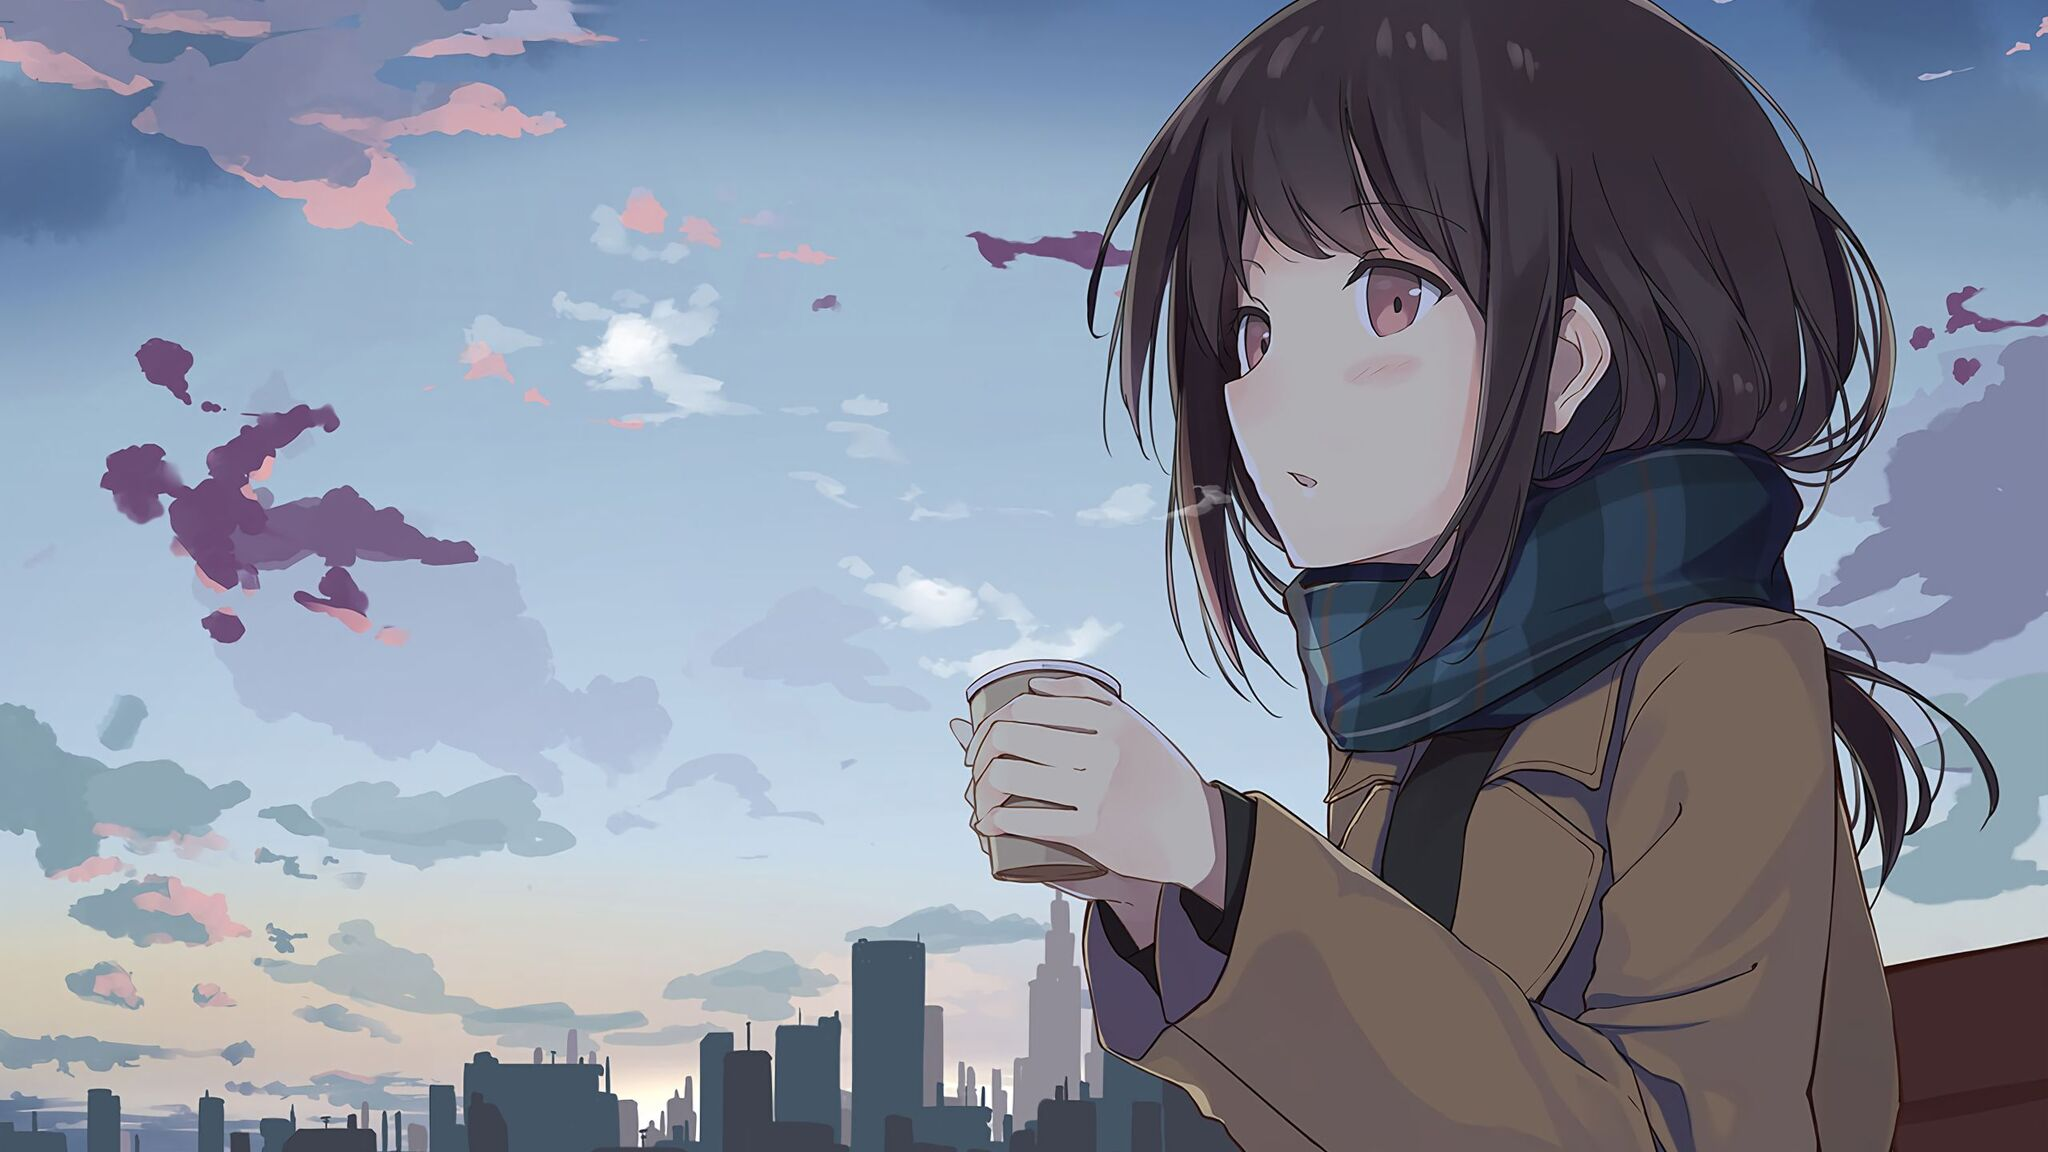


Candidate descriptions:
1. 12.68% - a photo of a cat
2. 3.62% - a photo of a dog
3. 0.99% - a photo of a car
4. 82.71% - a photo of a person

BEST MATCH:
a photo of a person


In [10]:
# Select a test image.
# Prefer the uploaded image; otherwise use the first downloaded sample.

if user_image is not None:
    test_image = user_image
elif sample_images:
    test_image = next(iter(sample_images.values()))
else:
    raise RuntimeError(
        "No image is available. Upload an image in Section 7."
    )

display(test_image)

candidate_texts = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a car",
    "a photo of a person",
]

scores, image_embeddings, text_embeddings = match_image_to_texts(
    test_image,
    candidate_texts
)

best_index = int(np.argmax(scores))

print("\nCandidate descriptions:")
for index, (text, score) in enumerate(
    zip(candidate_texts, scores),
    start=1
):
    print(f"{index}. {score * 100:.2f}% - {text}")

print("\nBEST MATCH:")
print(candidate_texts[best_index])

## 10. Manual Cosine Similarity

In [11]:
# Normalize CLIP's projected embeddings.
normalized_image = image_embeddings / image_embeddings.norm(
    dim=-1,
    keepdim=True
)

normalized_text = text_embeddings / text_embeddings.norm(
    dim=-1,
    keepdim=True
)

# Cosine similarity between the image and every text embedding.
cosine_scores = (normalized_image @ normalized_text.T)[0]

print("Cosine similarity scores:")
for text, score in zip(candidate_texts, cosine_scores.cpu().numpy()):
    print(f"{score:.4f} - {text}")

Cosine similarity scores:
0.2077 - a photo of a cat
0.1952 - a photo of a dog
0.1822 - a photo of a car
0.2265 - a photo of a person


### Important note about scores

The cosine similarity is the semantic similarity between the normalized image and text embeddings.

The softmax percentages shown earlier are **relative to the candidate descriptions supplied to the model**. They should not be interpreted as absolute probabilities that a description is true.

## 11. Verify CLIP's Logit-Based Scores

In [13]:
# CLIP applies a learned temperature/logit scale to the cosine similarities.
manual_logits = model.logit_scale.exp() * cosine_scores
manual_scores = torch.softmax(manual_logits, dim=0).detach().cpu().numpy()

print("CLIP logit scale:", model.logit_scale.exp().item())
print("\nManual relative scores:")

for text, score in zip(candidate_texts, manual_scores):
    print(f"{score * 100:.2f}% - {text}")

print(
    "\nMatches model softmax:",
    np.allclose(manual_scores, scores, atol=1e-4)
)

CLIP logit scale: 100.00000762939453

Manual relative scores:
12.68% - a photo of a cat
3.62% - a photo of a dog
0.99% - a photo of a car
82.71% - a photo of a person

Matches model softmax: True


## 12. Visualize Results

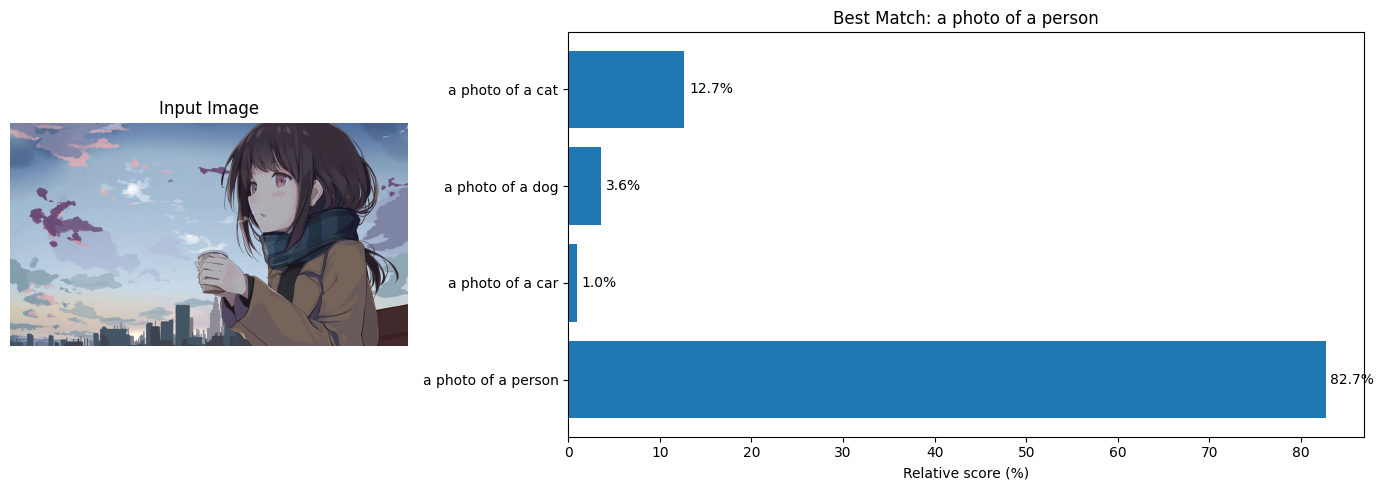

In [14]:
def show_matching_results(image, texts, scores):
    best = int(np.argmax(scores))

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5),
        gridspec_kw={"width_ratios": [1, 2]}
    )

    axes[0].imshow(image)
    axes[0].axis("off")
    axes[0].set_title("Input Image")

    y_positions = np.arange(len(texts))

    axes[1].barh(y_positions, scores * 100)
    axes[1].set_yticks(y_positions)
    axes[1].set_yticklabels(texts)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Relative score (%)")
    axes[1].set_title(
        "Best Match: " + texts[best]
    )

    for y, score in zip(y_positions, scores):
        axes[1].text(
            score * 100 + 0.5,
            y,
            f"{score * 100:.1f}%",
            va="center"
        )

    plt.tight_layout()
    plt.show()


show_matching_results(
    test_image,
    candidate_texts,
    scores
)

## 13. Rank All Candidate Descriptions

In [15]:
ranking_indices = np.argsort(scores)[::-1]

print("Ranking from highest to lowest:")
print()

for rank, index in enumerate(ranking_indices, start=1):
    print(
        f"{rank}. "
        f"{scores[index] * 100:.2f}% - "
        f"{candidate_texts[index]}"
    )

Ranking from highest to lowest:

1. 82.71% - a photo of a person
2. 12.68% - a photo of a cat
3. 3.62% - a photo of a dog
4. 0.99% - a photo of a car


## 14. Multiple Image Test

In [16]:
shared_texts = [
    "a photo of cats",
    "a photo of a stop sign",
    "a photo of a bedroom",
    "a photo of a living room",
    "a photo of a bear",
    "a photo of a pizza",
]

if sample_images:
    print(f"{'Image':<18} {'Best Match':<35} {'Score':>10}")
    print("-" * 70)

    for name, image in sample_images.items():
        image_scores, _, _ = match_image_to_texts(
            image,
            shared_texts
        )

        best = int(np.argmax(image_scores))

        print(
            f"{name:<18} "
            f"{shared_texts[best]:<35} "
            f"{image_scores[best] * 100:>8.2f}%"
        )
else:
    print("No sample images available.")

No sample images available.


## 15. Similarity Matrix

In [17]:
if sample_images:
    image_names = list(sample_images.keys())

    matrix = np.array([
        match_image_to_texts(
            sample_images[name],
            shared_texts
        )[0]
        for name in image_names
    ])

    plt.figure(figsize=(13, 6))
    plt.imshow(matrix, aspect="auto")

    plt.xticks(
        range(len(shared_texts)),
        shared_texts,
        rotation=35,
        ha="right"
    )

    plt.yticks(
        range(len(image_names)),
        image_names
    )

    plt.xlabel("Candidate text")
    plt.ylabel("Image")
    plt.title("Image–Text Relative Score Matrix")
    plt.colorbar(label="Relative score")

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(
                j,
                i,
                f"{matrix[i, j]:.2f}",
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()
else:
    print("No sample images available.")

No sample images available.


## 16. Interactive Matcher

BEST MATCH
a person outdoors
Relative score: 98.94%


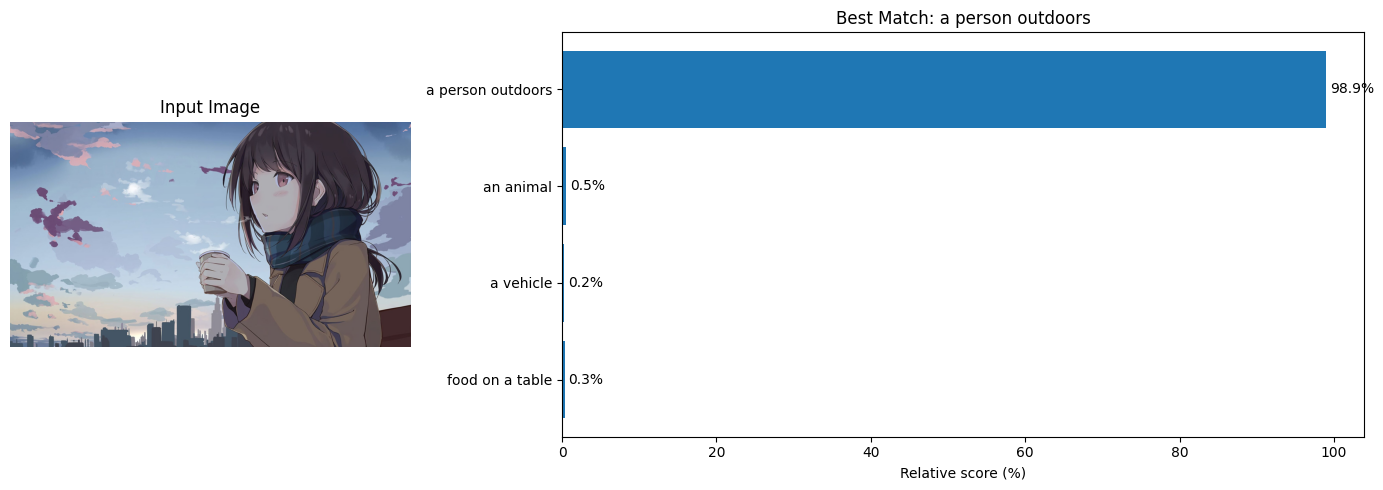

In [18]:
def image_text_matcher(image_source, descriptions):
    """Run the complete matching pipeline for a supplied image."""

    image = (
        image_source.convert("RGB")
        if isinstance(image_source, Image.Image)
        else load_image(image_source)
    )

    scores, _, _ = match_image_to_texts(
        image,
        descriptions
    )

    best_index = int(np.argmax(scores))

    print("BEST MATCH")
    print(descriptions[best_index])
    print(f"Relative score: {scores[best_index] * 100:.2f}%")

    show_matching_results(
        image,
        descriptions,
        scores
    )

    return descriptions[best_index], scores


# Example:
if user_image is not None:
    image_text_matcher(
        user_image,
        [
            "a person outdoors",
            "an animal",
            "a vehicle",
            "food on a table",
        ]
    )
else:
    print(
        "Upload an image in Section 7 to run the interactive example."
    )

## 17. Project Applications

- Image search using natural-language queries
- E-commerce product matching
- Digital asset management
- Accessibility support
- Social media image–caption matching
- Media and document retrieval
- Visual search systems

## 18. Advantages

- Uses a pre-trained multimodal model.
- No project-specific model training is required.
- Supports zero-shot image–text matching.
- Candidate descriptions can be changed without retraining.
- Can be extended to image retrieval systems.

## 19. Limitations

- Results depend on the candidate descriptions.
- Prompt wording can affect results.
- Exact counting and detailed spatial reasoning can be difficult.
- Softmax scores are relative to the supplied candidates.
- CLIP may contain biases inherited from its training data.
- The project ranks supplied descriptions; it does not independently generate a new caption.

## 20. Future Scope

1. Build a Streamlit or Gradio interface.
2. Store image embeddings for a large image collection.
3. Use FAISS for fast semantic image retrieval.
4. Add an image-captioning model such as BLIP.
5. Add multilingual text matching.
6. Adapt the system for domains such as products, fashion, documents, or education.

## 21. Conclusion

The Image–Text Matching System uses CLIP to place an image and candidate descriptions into a shared semantic representation.

The final pipeline is:

```text
Image + Candidate Texts
          ↓
      CLIP Processor
          ↓
      CLIP Encoders
       ↙         ↘
Image Embedding  Text Embeddings
       ↘         ↙
     Similarity
          ↓
       Ranking
          ↓
Best Matching Description
```

The project demonstrates how a pre-trained vision-language model can perform semantic image–text matching without training a new classifier.

## 22. Viva Questions

**Q1. What is CLIP?**  
CLIP is a multimodal model that learns aligned representations for images and text.

**Q2. Why is CLIP used?**  
It allows an image to be compared semantically with natural-language descriptions.

**Q3. What are the two main CLIP encoders?**  
An image encoder and a text encoder.

**Q4. What is an embedding?**  
An embedding is a numerical vector representation of an input.

**Q5. What similarity measure is used?**  
Cosine similarity can be used to compare normalized image and text embeddings.

**Q6. What is zero-shot matching?**  
Matching new image/text concepts without training a new task-specific classifier.

**Q7. Does a 90% softmax score mean 90% truth?**  
No. It is a relative score among the candidate descriptions supplied.

**Q8. Is the CLIP model trained in this project?**  
No. The project uses a pre-trained model for inference.

**Q9. What is the main limitation?**  
Results depend on candidate descriptions and prompt wording, and CLIP is not perfect at exact counting or fine spatial reasoning.

## 23. References

1. Radford, A., et al. (2021). *Learning Transferable Visual Models From Natural Language Supervision.*
2. Hugging Face Transformers — CLIP model implementation.
3. OpenAI CLIP project.
4. COCO 2017 dataset — demonstration images.